In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/ssvep-benchmark-dataset/S2.mat
/kaggle/input/ssvep-benchmark-dataset/S19.mat
/kaggle/input/ssvep-benchmark-dataset/S24.mat
/kaggle/input/ssvep-benchmark-dataset/S5.mat
/kaggle/input/ssvep-benchmark-dataset/S6.mat
/kaggle/input/ssvep-benchmark-dataset/S23.mat
/kaggle/input/ssvep-benchmark-dataset/S15.mat
/kaggle/input/ssvep-benchmark-dataset/S22.mat
/kaggle/input/ssvep-benchmark-dataset/S10.mat
/kaggle/input/ssvep-benchmark-dataset/64-channels.loc
/kaggle/input/ssvep-benchmark-dataset/S30.mat
/kaggle/input/ssvep-benchmark-dataset/S35.mat
/kaggle/input/ssvep-benchmark-dataset/S18.mat
/kaggle/input/ssvep-benchmark-dataset/S8.mat
/kaggle/input/ssvep-benchmark-dataset/S17.mat
/kaggle/input/ssvep-benchmark-dataset/S25.mat
/kaggle/input/ssvep-benchmark-dataset/S16.mat
/kaggle/input/ssvep-benchmark-dataset/S27.mat
/kaggle/input/ssvep-benchmark-dataset/S7.mat
/kaggle/input/ssvep-benchmark-dataset/Readme.txt
/kaggle/input/ssvep-benchmark-dataset/S14.mat
/kaggle/input/ssvep-benchmar

In [2]:
DATA_DIR = "/kaggle/input/ssvep-benchmark-dataset"
SUBJECT_FILE = f"{DATA_DIR}/S1.mat"
FREQ_FILE = f"{DATA_DIR}/Freq_Phase.mat"
LOC_FILE = f"{DATA_DIR}/64-channels.loc"

In [3]:
import numpy as np
import scipy.io as sio

fs = 250  # downsampled sampling rate :contentReference[oaicite:2]{index=2}

mat = sio.loadmat(SUBJECT_FILE)
data = mat["data"]

print("data shape:", data.shape)  # (64, 1500, 40, 6)

fp = sio.loadmat(FREQ_FILE)
freqs = fp["freqs"].squeeze()
phases = fp["phases"].squeeze()

print("freqs shape:", freqs.shape)     # (40,)
print("first 10 freqs:", freqs[:10])


data shape: (64, 1500, 40, 6)
freqs shape: (40,)
first 10 freqs: [ 8.   9.  10.  11.  12.  13.  14.  15.   8.2  9.2]


In [4]:
def parse_loc_file(loc_path):
    # columns: index, degree, radius, label :contentReference[oaicite:4]{index=4}
    labels = []
    with open(loc_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # last field is label
            label = parts[-1]
            labels.append(label)
    return labels

labels = parse_loc_file(LOC_FILE)
print("Total labels:", len(labels))
print("First 10 labels:", labels[:10])

# map label -> index
label_to_idx = {lab: i for i, lab in enumerate(labels)}

# electrodes used in Fig.3 averaging
roi_labels = ["Pz","PO5","PO3","POz","PO4","PO6","O1","Oz","O2"]
roi_idx = [label_to_idx[l] for l in roi_labels if l in label_to_idx]

print("ROI indices:", roi_idx)


Total labels: 64
First 10 labels: ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ']
ROI indices: [53, 54, 55, 56, 57, 60, 61, 62]


In [5]:
stim_start = int(0.5 * fs)  # 125
stim_end   = int(5.5 * fs)  # 1375

def get_trial(subject_data, target_idx, block_idx):
    trial = subject_data[:, :, target_idx, block_idx]  # (64,1500)
    stim = trial[:, stim_start:stim_end]               # (64,1250)
    return trial, stim

Closest target to 15Hz: 38 freq: 14.8
Oz index: 61


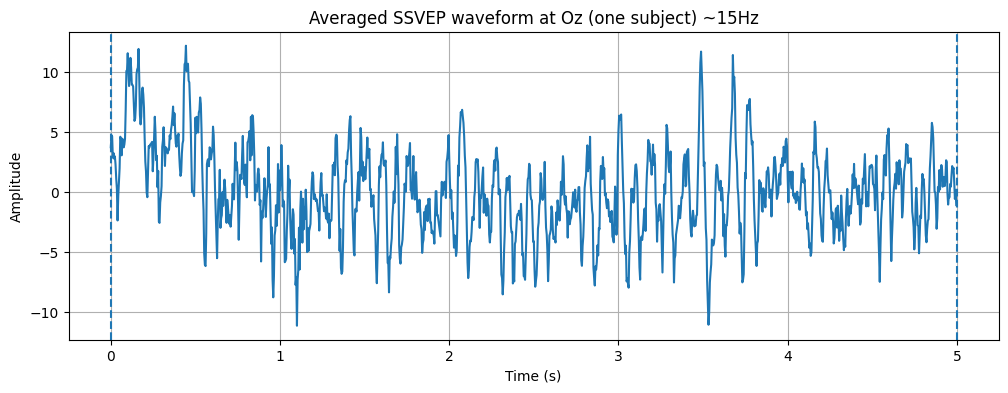

In [6]:
import matplotlib.pyplot as plt

# find target index closest to 15 Hz
target_15 = int(np.argmin(np.abs(freqs - 14.8)))
print("Closest target to 15Hz:", target_15, "freq:", freqs[target_15])

oz_idx = label_to_idx.get("Oz", None)
print("Oz index:", oz_idx)

# average across 6 blocks for this target
oz_blocks = []
for b in range(6):
    _, stim = get_trial(data, target_15, b)
    oz_blocks.append(stim[oz_idx])

oz_avg = np.mean(np.stack(oz_blocks, axis=0), axis=0)
t_stim = np.arange(len(oz_avg))/fs

plt.figure(figsize=(12,4))
plt.plot(t_stim, oz_avg)
plt.axvline(0, linestyle="--")
plt.axvline(5, linestyle="--")
plt.title("Averaged SSVEP waveform at Oz (one subject) ~15Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


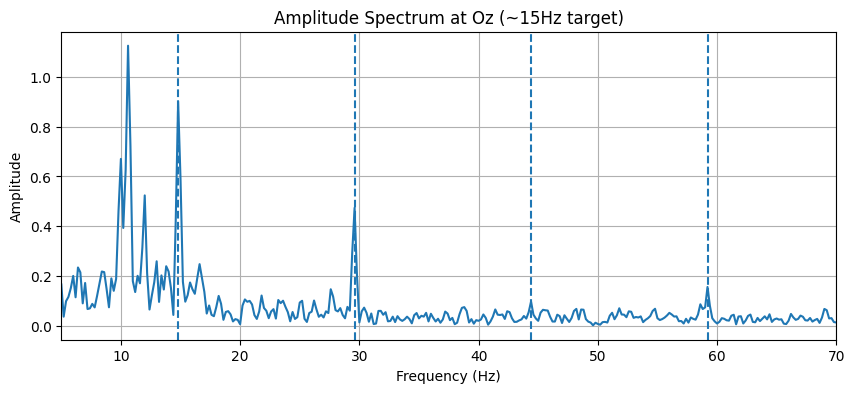

In [7]:
def amplitude_spectrum(x, fs):
    x = x - np.mean(x)
    N = len(x)
    window = np.hanning(N)
    X = np.fft.rfft(x * window)
    f = np.fft.rfftfreq(N, 1/fs)
    amp = (2.0 / N) * np.abs(X)
    return f, amp

f, amp = amplitude_spectrum(oz_avg, fs)

plt.figure(figsize=(10,4))
plt.plot(f, amp)
plt.xlim(5, 70)
plt.title("Amplitude Spectrum at Oz (~15Hz target)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

f0 = freqs[target_15]
for k in range(1,5):
    plt.axvline(k*f0, linestyle="--")

plt.show()


## Step 0 — Load dataset and define a test trial

In [8]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/ssvep-benchmark-dataset"
SUBJECT_FILE = f"{DATA_DIR}/S1.mat"
FREQ_FILE = f"{DATA_DIR}/Freq_Phase.mat"
LOC_FILE = f"{DATA_DIR}/64-channels.loc"

fs = 250  # Hz

# Load EEG
mat = sio.loadmat(SUBJECT_FILE)
data = mat["data"]  # (64,1500,40,6)

# Load frequency list (40 targets)
fp = sio.loadmat(FREQ_FILE)
freqs = fp["freqs"].squeeze()

print("EEG data shape:", data.shape)
print("Target frequencies (first 10):", freqs[:10])


EEG data shape: (64, 1500, 40, 6)
Target frequencies (first 10): [ 8.   9.  10.  11.  12.  13.  14.  15.   8.2  9.2]


## Step 1 — Extract EEG X and Build Reference Y for one candidate frequency

In [9]:
stim_start = int(0.5 * fs)   # 125
stim_end   = int(5.5 * fs)   # 1375

# pick one trial to test
target_true = 0   # true label (0..39)
block = 0         # 0..5

trial = data[:, :, target_true, block]       # (64,1500)
X = trial[:, stim_start:stim_end]            # (64,1250)

print("X shape:", X.shape, "| true stim freq:", freqs[target_true])

X shape: (64, 1250) | true stim freq: 8.0


In [10]:
def build_reference(f, fs, n_samples, n_harmonics=5):
    t = np.arange(n_samples) / fs
    Y = []
    for h in range(1, n_harmonics + 1):
        Y.append(np.sin(2*np.pi*h*f*t))
        Y.append(np.cos(2*np.pi*h*f*t))
    return np.array(Y)  # shape: (2*n_harmonics, n_samples)

Y = build_reference(freqs[target_true], fs, X.shape[1], n_harmonics=5)
print("Y shape:", Y.shape)


Y shape: (10, 1250)


##  Step 2 — Build Weight Matrix W (Temporal locality)

In [11]:
def build_weight_matrix(M, s, r=3):
    """
    M = number of samples
    s = neighborhood range in samples (integer)
    r = shape parameter (paper uses r=3)
    """
    idx = np.arange(M)
    dist = np.abs(idx[:, None] - idx[None, :])
    m = dist / s
    
    W = np.zeros((M, M), dtype=np.float64)
    mask = (m < 1)
    W[mask] = (1 - np.abs(m[mask])**r)**r
    return W

M = X.shape[1]
s = 25  # ~0.1s neighborhood (25 samples at 250Hz)
W = build_weight_matrix(M, s=s, r=3)

print("W shape:", W.shape, "W nonzero ratio:", np.mean(W > 0))


W shape: (1250, 1250) W nonzero ratio: 0.038816


## Step 3 — Laplacian matrix L = D − W

In [12]:
def laplacian_from_W(W):
    D = np.diag(W.sum(axis=1))
    return D - W

L = laplacian_from_W(W)
print("L shape:", L.shape)


L shape: (1250, 1250)


## Step 4 — Temporally Local Covariance matrix

In [13]:
def temporally_local_covariance(Z, L):
    M = Z.shape[1]
    return (Z @ L @ Z.T) / M

# stack EEG + ref
Z = np.vstack([X, Y])  # shape: (64 + 10, 1250)
C = temporally_local_covariance(Z, L)

print("Z shape:", Z.shape)
print("C shape:", C.shape)


Z shape: (74, 1250)
C shape: (74, 74)


In [14]:
def inv_sqrtm(A, eps=1e-10):
    # A should be symmetric PSD
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def compute_R_from_C(C, n_eeg):
    C11 = C[:n_eeg, :n_eeg]
    C22 = C[n_eeg:, n_eeg:]
    C12 = C[:n_eeg, n_eeg:]
    C21 = C[n_eeg:, :n_eeg]

    C11_inv_sqrt = inv_sqrtm(C11)
    C22_inv_sqrt = inv_sqrtm(C22)

    # block U
    top = np.hstack([C11_inv_sqrt, np.zeros((C11.shape[0], C22.shape[0]))])
    bot = np.hstack([np.zeros((C22.shape[0], C11.shape[0])), C22_inv_sqrt])
    U = np.vstack([top, bot])

    R = U @ C @ U.T
    return R

n_eeg = X.shape[0]
R = compute_R_from_C(C, n_eeg=n_eeg)

print("R shape:", R.shape)


R shape: (74, 74)


In [15]:
eigvals = np.linalg.eigvalsh(R)
eigvals = np.maximum(eigvals, 1e-12)  # numerical safety
lam = eigvals / np.sum(eigvals)

print("Eigenvalues count:", len(lam))
print("Sum of normalized eigenvalues:", lam.sum())


Eigenvalues count: 74
Sum of normalized eigenvalues: 1.0


In [16]:
def synchronization_index(lam):
    P = len(lam)
    return 1 + (np.sum(lam * np.log(lam))) / np.log(P)

S = synchronization_index(lam)
print("Synchronization score S:", S)


Synchronization score S: 0.004647399773162975


In [17]:
def tmsi_score_for_frequency(X, f, fs, L, n_harmonics=5):
    Y = build_reference(f, fs, X.shape[1], n_harmonics)
    Z = np.vstack([X, Y])
    C = temporally_local_covariance(Z, L)
    R = compute_R_from_C(C, n_eeg=X.shape[0])
    eigvals = np.linalg.eigvalsh(R)
    eigvals = np.maximum(eigvals, 1e-12)
    lam = eigvals / np.sum(eigvals)
    return synchronization_index(lam)

scores = []
for f in freqs:
    scores.append(tmsi_score_for_frequency(X, f, fs, L, n_harmonics=5))

scores = np.array(scores)
pred_target = int(np.argmax(scores))

print("True target:", target_true, "| True freq:", freqs[target_true])
print("Pred target:", pred_target, "| Pred freq:", freqs[pred_target], "| Score:", scores[pred_target])


True target: 0 | True freq: 8.0
Pred target: 0 | Pred freq: 8.0 | Score: 0.004647399773162975


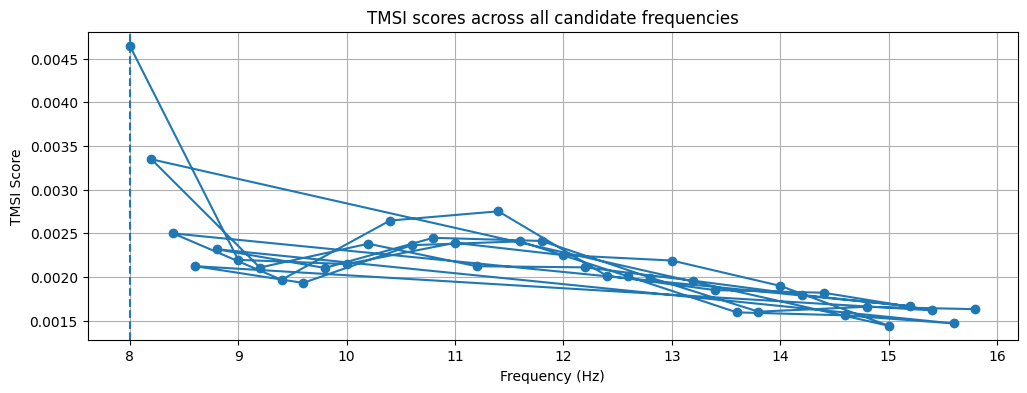

In [18]:
plt.figure(figsize=(12,4))
plt.plot(freqs, scores, marker="o")
plt.axvline(freqs[target_true], linestyle="--")
plt.title("TMSI scores across all candidate frequencies")
plt.xlabel("Frequency (Hz)")
plt.ylabel("TMSI Score")
plt.grid(True)
plt.show()


In [19]:
stim_start = int(0.5 * fs)  # 125
stim_end = int(5.5 * fs)    # 1375  (1250 samples)

# window lengths (seconds)
window_secs = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]


In [20]:
import numpy as np
import scipy.io as sio

# -----------------------------
# Paths + Load data
# -----------------------------
DATA_DIR = "/kaggle/input/ssvep-benchmark-dataset"
SUBJECT_FILE = f"{DATA_DIR}/S2.mat"
FREQ_FILE = f"{DATA_DIR}/Freq_Phase.mat"

fs = 250

mat = sio.loadmat(SUBJECT_FILE)
data = mat["data"]  # (64,1500,40,6)

fp = sio.loadmat(FREQ_FILE)
freqs = fp["freqs"].squeeze()

print("Loaded data shape:", data.shape)
print("Loaded freqs shape:", freqs.shape)

# -----------------------------
# ✅ Window control (seconds)
# -----------------------------
# Change this value to test different windows: 0.25, 0.5, 1, 2, 3, 4, 5
window_sec = 5.0

# Trial structure: 0.5s pre-stim, 5s stim, 0.5s post-stim
stim_start = int(0.5 * fs)
stim_end = stim_start + int(window_sec * fs)

# Safety: don't exceed the trial length (1500 samples)
stim_end = min(stim_end, data.shape[1])

M = stim_end - stim_start

print(f"\nUsing window_sec={window_sec}s")
print(f"stim_start={stim_start}, stim_end={stim_end}, M(samples)={M}\n")


# -----------------------------
# Step 1: reference builder
# -----------------------------
def build_reference(f, fs, n_samples, n_harmonics=5):
    t = np.arange(n_samples) / fs
    Y = []
    for h in range(1, n_harmonics + 1):
        Y.append(np.sin(2*np.pi*h*f*t))
        Y.append(np.cos(2*np.pi*h*f*t))
    return np.array(Y)  # (2*n_harmonics, n_samples)

# -----------------------------
# Step 2: W and Laplacian
# -----------------------------
def build_weight_matrix(M, s, r=3):
    idx = np.arange(M)
    dist = np.abs(idx[:, None] - idx[None, :])
    m = dist / s

    W = np.zeros((M, M), dtype=np.float64)
    mask = (m < 1)
    W[mask] = (1 - np.abs(m[mask])**r)**r
    return W

def laplacian_from_W(W):
    D = np.diag(W.sum(axis=1))
    return D - W

# -----------------------------
# Step 3: temporally local covariance
# -----------------------------
def temporally_local_covariance(Z, L):
    M = Z.shape[1]
    return (Z @ L @ Z.T) / M

# -----------------------------
# Step 4: whitening and score
# -----------------------------
def inv_sqrtm(A, eps=1e-10):
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def compute_R_from_C(C, n_eeg):
    C11 = C[:n_eeg, :n_eeg]
    C22 = C[n_eeg:, n_eeg:]

    C11_inv_sqrt = inv_sqrtm(C11)
    C22_inv_sqrt = inv_sqrtm(C22)

    top = np.hstack([C11_inv_sqrt, np.zeros((C11.shape[0], C22.shape[0]))])
    bot = np.hstack([np.zeros((C22.shape[0], C11.shape[0])), C22_inv_sqrt])
    U = np.vstack([top, bot])

    R = U @ C @ U.T
    return R

def synchronization_index(lam):
    P = len(lam)
    return 1 + (np.sum(lam * np.log(lam))) / np.log(P)

def score_from_C(C, n_eeg):
    R = compute_R_from_C(C, n_eeg)
    eigvals = np.linalg.eigvalsh(R)
    eigvals = np.maximum(eigvals, 1e-12)
    lam = eigvals / np.sum(eigvals)
    return synchronization_index(lam)

# -----------------------------
# TMSI scoring for one frequency
# -----------------------------
def tmsi_score_for_frequency(X, f, fs, L, n_harmonics=5):
    Y = build_reference(f, fs, X.shape[1], n_harmonics)
    Z = np.vstack([X, Y])
    C = temporally_local_covariance(Z, L)
    return score_from_C(C, n_eeg=X.shape[0])

# -----------------------------
# Predict frequency from all candidates
# -----------------------------
def tmsi_predict(X, freqs, fs, L, n_harmonics=5):
    scores = np.zeros(len(freqs), dtype=np.float64)
    for i, f in enumerate(freqs):
        scores[i] = tmsi_score_for_frequency(X, f, fs, L, n_harmonics)
    pred_target = int(np.argmax(scores))
    return pred_target, scores


# -----------------------------
# ✅ Build Laplacian ONCE for this window length M
# -----------------------------
s_local = 25  # neighborhood in samples (~0.1s at 250Hz)
r = 3

W = build_weight_matrix(M, s=s_local, r=r)
L = laplacian_from_W(W)

print("Built Laplacian L:", L.shape)

# -----------------------------
# Run all 240 trials
# -----------------------------
n_harmonics = 5

total = 0
correct = 0

print("\n===== TMSI Results for Subject S1 (240 trials) =====\n")

for block in range(6):
    for target_true in range(40):

        # Extract trial EEG
        trial = data[:, :, target_true, block]     # (64,1500)
        X = trial[:, stim_start:stim_end]          # (64,M)

        pred_target, scores = tmsi_predict(X, freqs, fs, L, n_harmonics=n_harmonics)

        pred_score = float(scores[pred_target])
        true_score = float(scores[target_true])
        is_correct = (pred_target == target_true)

        total += 1
        correct += int(is_correct)

        print(
            f"Block {block+1} | Target {target_true:02d} | "
            f"True {freqs[target_true]:>4.1f} Hz | "
            f"Pred {pred_target:02d} ({freqs[pred_target]:>4.1f} Hz) | "
            f"PredScore {pred_score:.6f} | TrueScore {true_score:.6f} | "
            f"{'✅' if is_correct else '❌'}"
        )

acc = correct / total
print("\n==============================================")
print(f"Final Accuracy (Subject S1): {acc*100:.2f}% ({correct}/{total})")
print("==============================================\n")


Loaded data shape: (64, 1500, 40, 6)
Loaded freqs shape: (40,)

Using window_sec=5.0s
stim_start=125, stim_end=1375, M(samples)=1250

Built Laplacian L: (1250, 1250)

===== TMSI Results for Subject S1 (240 trials) =====

Block 1 | Target 00 | True  8.0 Hz | Pred 00 ( 8.0 Hz) | PredScore 0.004559 | TrueScore 0.004559 | ✅
Block 1 | Target 01 | True  9.0 Hz | Pred 01 ( 9.0 Hz) | PredScore 0.004587 | TrueScore 0.004587 | ✅
Block 1 | Target 02 | True 10.0 Hz | Pred 02 (10.0 Hz) | PredScore 0.004272 | TrueScore 0.004272 | ✅
Block 1 | Target 03 | True 11.0 Hz | Pred 03 (11.0 Hz) | PredScore 0.005878 | TrueScore 0.005878 | ✅
Block 1 | Target 04 | True 12.0 Hz | Pred 04 (12.0 Hz) | PredScore 0.005311 | TrueScore 0.005311 | ✅
Block 1 | Target 05 | True 13.0 Hz | Pred 19 (11.4 Hz) | PredScore 0.003899 | TrueScore 0.003870 | ❌
Block 1 | Target 06 | True 14.0 Hz | Pred 06 (14.0 Hz) | PredScore 0.004027 | TrueScore 0.004027 | ✅
Block 1 | Target 07 | True 15.0 Hz | Pred 05 (13.0 Hz) | PredScore 0.003

In [21]:
import numpy as np
import scipy.io as sio

# -----------------------------
# Paths + Load data
# -----------------------------
DATA_DIR = "/kaggle/input/ssvep-benchmark-dataset"
SUBJECT_FILE = f"{DATA_DIR}/S2.mat"
FREQ_FILE = f"{DATA_DIR}/Freq_Phase.mat"
LOC_FILE = f"{DATA_DIR}/64-channels.loc"

fs = 250

mat = sio.loadmat(SUBJECT_FILE)
data = mat["data"]  # (64,1500,40,6)

fp = sio.loadmat(FREQ_FILE)
freqs = fp["freqs"].squeeze()

print("Loaded data shape:", data.shape)
print("Loaded freqs shape:", freqs.shape)

# -----------------------------
# ✅ Version A: ROI channels + latency shift
# -----------------------------
roi_labels = ["Pz", "PO5", "PO3", "POz", "PO4", "PO6", "O1", "Oz", "O2"]

def parse_loc_file(loc_path):
    labels = []
    with open(loc_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            labels.append(line.split()[-1])
    return labels

labels = parse_loc_file(LOC_FILE)
label_to_idx = {lab: i for i, lab in enumerate(labels)}

roi_idx = []
missing = []
for lab in roi_labels:
    if lab in label_to_idx:
        roi_idx.append(label_to_idx[lab])
    else:
        missing.append(lab)

if len(missing) > 0:
    print("⚠️ Missing ROI labels in loc file:", missing)

roi_idx = np.array(roi_idx, dtype=int)
print("ROI indices:", roi_idx)
print("Using ROI channel count:", len(roi_idx))

# -----------------------------
# ✅ Window control (seconds)
# -----------------------------
window_sec = 2.0   # try 0.25, 0.5, 1, 2, 3, 4, 5
latency_sec = 0.14 # 140 ms latency shift (dataset paper style)

# Stimulation starts at 0.5s in epoch
stim_onset = 0.5

start_time = stim_onset + latency_sec
stim_start = int(start_time * fs)

stim_end = stim_start + int(window_sec * fs)

# Safety: don't exceed the trial length (1500 samples)
stim_end = min(stim_end, data.shape[1])

M = stim_end - stim_start

print(f"\nUsing window_sec={window_sec}s with latency={latency_sec}s")
print(f"stim_start={stim_start} ({stim_start/fs:.3f}s), stim_end={stim_end} ({stim_end/fs:.3f}s)")
print(f"M(samples)={M}\n")

# -----------------------------
# Step 1: reference builder
# -----------------------------
def build_reference(f, fs, n_samples, n_harmonics=5):
    t = np.arange(n_samples) / fs
    Y = []
    for h in range(1, n_harmonics + 1):
        Y.append(np.sin(2*np.pi*h*f*t))
        Y.append(np.cos(2*np.pi*h*f*t))
    return np.array(Y)  # (2*n_harmonics, n_samples)

# -----------------------------
# Step 2: W and Laplacian
# -----------------------------
def build_weight_matrix(M, s, r=3):
    idx = np.arange(M)
    dist = np.abs(idx[:, None] - idx[None, :])
    m = dist / s

    W = np.zeros((M, M), dtype=np.float64)
    mask = (m < 1)
    W[mask] = (1 - np.abs(m[mask])**r)**r
    return W

def laplacian_from_W(W):
    D = np.diag(W.sum(axis=1))
    return D - W

# -----------------------------
# Step 3: temporally local covariance
# -----------------------------
def temporally_local_covariance(Z, L):
    M = Z.shape[1]
    return (Z @ L @ Z.T) / M

# -----------------------------
# Step 4: whitening and score
# -----------------------------
def inv_sqrtm(A, eps=1e-10):
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def compute_R_from_C(C, n_eeg):
    C11 = C[:n_eeg, :n_eeg]
    C22 = C[n_eeg:, n_eeg:]

    C11_inv_sqrt = inv_sqrtm(C11)
    C22_inv_sqrt = inv_sqrtm(C22)

    top = np.hstack([C11_inv_sqrt, np.zeros((C11.shape[0], C22.shape[0]))])
    bot = np.hstack([np.zeros((C22.shape[0], C11.shape[0])), C22_inv_sqrt])
    U = np.vstack([top, bot])

    R = U @ C @ U.T
    return R

def synchronization_index(lam):
    P = len(lam)
    return 1 + (np.sum(lam * np.log(lam))) / np.log(P)

def score_from_C(C, n_eeg):
    R = compute_R_from_C(C, n_eeg)
    eigvals = np.linalg.eigvalsh(R)
    eigvals = np.maximum(eigvals, 1e-12)
    lam = eigvals / np.sum(eigvals)
    return synchronization_index(lam)

# -----------------------------
# TMSI scoring for one frequency
# -----------------------------
def tmsi_score_for_frequency(X, f, fs, L, n_harmonics=5):
    Y = build_reference(f, fs, X.shape[1], n_harmonics)
    Z = np.vstack([X, Y])
    C = temporally_local_covariance(Z, L)
    return score_from_C(C, n_eeg=X.shape[0])

# -----------------------------
# Predict frequency from all candidates
# -----------------------------
def tmsi_predict(X, freqs, fs, L, n_harmonics=5):
    scores = np.zeros(len(freqs), dtype=np.float64)
    for i, f in enumerate(freqs):
        scores[i] = tmsi_score_for_frequency(X, f, fs, L, n_harmonics)
    pred_target = int(np.argmax(scores))
    return pred_target, scores

# -----------------------------
# ✅ Build Laplacian ONCE for this window length M
# -----------------------------
s_local = 25  # neighborhood in samples (~0.1s at 250Hz)
r = 3

W = build_weight_matrix(M, s=s_local, r=r)
L = laplacian_from_W(W)

print("Built Laplacian L:", L.shape)

# -----------------------------
# Run all 240 trials
# -----------------------------
n_harmonics = 5

total = 0
correct = 0

print("\n===== TMSI Results for Subject S2 (240 trials) [ROI + latency] =====\n")

for block in range(6):
    for target_true in range(40):

        # Extract trial EEG
        trial = data[:, :, target_true, block]     # (64,1500)

        # ✅ ROI channels only
        X = trial[roi_idx, stim_start:stim_end]    # (9,M)

        pred_target, scores = tmsi_predict(X, freqs, fs, L, n_harmonics=n_harmonics)

        pred_score = float(scores[pred_target])
        true_score = float(scores[target_true])
        is_correct = (pred_target == target_true)

        total += 1
        correct += int(is_correct)

        print(
            f"Block {block+1} | Target {target_true:02d} | "
            f"True {freqs[target_true]:>4.1f} Hz | "
            f"Pred {pred_target:02d} ({freqs[pred_target]:>4.1f} Hz) | "
            f"PredScore {pred_score:.6f} | TrueScore {true_score:.6f} | "
            f"{'✅' if is_correct else '❌'}"
        )

acc = correct / total
print("\n==============================================")
print(f"Final Accuracy (Subject S2): {acc*100:.2f}% ({correct}/{total})")
print("==============================================\n")


Loaded data shape: (64, 1500, 40, 6)
Loaded freqs shape: (40,)
⚠️ Missing ROI labels in loc file: ['Pz']
ROI indices: [53 54 55 56 57 60 61 62]
Using ROI channel count: 8

Using window_sec=2.0s with latency=0.14s
stim_start=160 (0.640s), stim_end=660 (2.640s)
M(samples)=500

Built Laplacian L: (500, 500)

===== TMSI Results for Subject S2 (240 trials) [ROI + latency] =====

Block 1 | Target 00 | True  8.0 Hz | Pred 00 ( 8.0 Hz) | PredScore 0.014265 | TrueScore 0.014265 | ✅
Block 1 | Target 01 | True  9.0 Hz | Pred 01 ( 9.0 Hz) | PredScore 0.014224 | TrueScore 0.014224 | ✅
Block 1 | Target 02 | True 10.0 Hz | Pred 02 (10.0 Hz) | PredScore 0.014001 | TrueScore 0.014001 | ✅
Block 1 | Target 03 | True 11.0 Hz | Pred 03 (11.0 Hz) | PredScore 0.023039 | TrueScore 0.023039 | ✅
Block 1 | Target 04 | True 12.0 Hz | Pred 04 (12.0 Hz) | PredScore 0.025788 | TrueScore 0.025788 | ✅
Block 1 | Target 05 | True 13.0 Hz | Pred 05 (13.0 Hz) | PredScore 0.015950 | TrueScore 0.015950 | ✅
Block 1 | Target 

o1, o2 and oz only

In [23]:
import numpy as np
import scipy.io as sio

# -----------------------------
# Paths + Load data
# -----------------------------
DATA_DIR = "/kaggle/input/ssvep-benchmark-dataset"
SUBJECT_FILE = f"{DATA_DIR}/S2.mat"
FREQ_FILE = f"{DATA_DIR}/Freq_Phase.mat"
LOC_FILE = f"{DATA_DIR}/64-channels.loc"

fs = 250

mat = sio.loadmat(SUBJECT_FILE)
data = mat["data"]  # (64,1500,40,6)

fp = sio.loadmat(FREQ_FILE)
freqs = fp["freqs"].squeeze()

print("Loaded data shape:", data.shape)
print("Loaded freqs shape:", freqs.shape)

# -----------------------------
# ✅ Use only O1, Oz, O2
# -----------------------------
use_labels = ["O1", "Oz", "O2"]

def parse_loc_file(loc_path):
    labels = []
    with open(loc_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            labels.append(line.split()[-1])
    return labels

labels = parse_loc_file(LOC_FILE)
label_to_idx = {lab: i for i, lab in enumerate(labels)}

use_idx = []
missing = []
for lab in use_labels:
    if lab in label_to_idx:
        use_idx.append(label_to_idx[lab])
    else:
        missing.append(lab)

if len(missing) > 0:
    print("⚠️ Missing labels:", missing)

use_idx = np.array(use_idx, dtype=int)
print("Using channels:", use_labels)
print("Channel indices:", use_idx)
print("Using channel count:", len(use_idx))

# -----------------------------
# ✅ Window control (seconds) + latency shift
# -----------------------------
window_sec = 3.0   # try 0.25, 0.5, 1, 2
latency_sec = 0.14 # 140 ms latency shift

stim_onset = 0.5  # stimulation starts at 0.5s in epoch
start_time = stim_onset + latency_sec

stim_start = int(start_time * fs)
stim_end = stim_start + int(window_sec * fs)

# Safety: don't exceed trial length
stim_end = min(stim_end, data.shape[1])
M = stim_end - stim_start

print(f"\nUsing window_sec={window_sec}s with latency={latency_sec}s")
print(f"stim_start={stim_start} ({stim_start/fs:.3f}s), stim_end={stim_end} ({stim_end/fs:.3f}s)")
print(f"M(samples)={M}\n")

# -----------------------------
# Step 1: reference builder
# -----------------------------
def build_reference(f, fs, n_samples, n_harmonics=5):
    t = np.arange(n_samples) / fs
    Y = []
    for h in range(1, n_harmonics + 1):
        Y.append(np.sin(2*np.pi*h*f*t))
        Y.append(np.cos(2*np.pi*h*f*t))
    return np.array(Y)

# -----------------------------
# Step 2: W and Laplacian
# -----------------------------
def build_weight_matrix(M, s, r=3):
    idx = np.arange(M)
    dist = np.abs(idx[:, None] - idx[None, :])
    m = dist / s

    W = np.zeros((M, M), dtype=np.float64)
    mask = (m < 1)
    W[mask] = (1 - np.abs(m[mask])**r)**r
    return W

def laplacian_from_W(W):
    D = np.diag(W.sum(axis=1))
    return D - W

# -----------------------------
# Step 3: temporally local covariance
# -----------------------------
def temporally_local_covariance(Z, L):
    M = Z.shape[1]
    return (Z @ L @ Z.T) / M

# -----------------------------
# Step 4: whitening and score
# -----------------------------
def inv_sqrtm(A, eps=1e-10):
    vals, vecs = np.linalg.eigh(A)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def compute_R_from_C(C, n_eeg):
    C11 = C[:n_eeg, :n_eeg]
    C22 = C[n_eeg:, n_eeg:]

    C11_inv_sqrt = inv_sqrtm(C11)
    C22_inv_sqrt = inv_sqrtm(C22)

    top = np.hstack([C11_inv_sqrt, np.zeros((C11.shape[0], C22.shape[0]))])
    bot = np.hstack([np.zeros((C22.shape[0], C11.shape[0])), C22_inv_sqrt])
    U = np.vstack([top, bot])

    R = U @ C @ U.T
    return R

def synchronization_index(lam):
    P = len(lam)
    return 1 + (np.sum(lam * np.log(lam))) / np.log(P)

def score_from_C(C, n_eeg):
    R = compute_R_from_C(C, n_eeg)
    eigvals = np.linalg.eigvalsh(R)
    eigvals = np.maximum(eigvals, 1e-12)
    lam = eigvals / np.sum(eigvals)
    return synchronization_index(lam)

# -----------------------------
# TMSI scoring for one frequency
# -----------------------------
def tmsi_score_for_frequency(X, f, fs, L, n_harmonics=5):
    Y = build_reference(f, fs, X.shape[1], n_harmonics)
    Z = np.vstack([X, Y])
    C = temporally_local_covariance(Z, L)
    return score_from_C(C, n_eeg=X.shape[0])

# -----------------------------
# Predict frequency from all candidates
# -----------------------------
def tmsi_predict(X, freqs, fs, L, n_harmonics=5):
    scores = np.zeros(len(freqs), dtype=np.float64)
    for i, f in enumerate(freqs):
        scores[i] = tmsi_score_for_frequency(X, f, fs, L, n_harmonics)
    pred_target = int(np.argmax(scores))
    return pred_target, scores

# -----------------------------
# ✅ Build Laplacian ONCE for this window length
# -----------------------------
s_local = 25
r = 3
W = build_weight_matrix(M, s=s_local, r=r)
L = laplacian_from_W(W)

print("Built Laplacian L:", L.shape)

# -----------------------------
# Run all 240 trials
# -----------------------------
n_harmonics = 5
total = 0
correct = 0

print("\n===== TMSI Results for Subject S2 (O1/Oz/O2 only) =====\n")

for block in range(6):
    for target_true in range(40):
        trial = data[:, :, target_true, block]     # (64,1500)
        X = trial[use_idx, stim_start:stim_end]    # (3,M)

        pred_target, scores = tmsi_predict(X, freqs, fs, L, n_harmonics=n_harmonics)

        pred_score = float(scores[pred_target])
        true_score = float(scores[target_true])
        is_correct = (pred_target == target_true)

        total += 1
        correct += int(is_correct)

        print(
            f"Block {block+1} | Target {target_true:02d} | "
            f"True {freqs[target_true]:>4.1f} Hz | "
            f"Pred {pred_target:02d} ({freqs[pred_target]:>4.1f} Hz) | "
            f"PredScore {pred_score:.6f} | TrueScore {true_score:.6f} | "
            f"{'✅' if is_correct else '❌'}"
        )

acc = correct / total
print("\n==============================================")
print(f"Final Accuracy (Subject S2): {acc*100:.2f}% ({correct}/{total})")
print("==============================================\n")


Loaded data shape: (64, 1500, 40, 6)
Loaded freqs shape: (40,)
Using channels: ['O1', 'Oz', 'O2']
Channel indices: [60 61 62]
Using channel count: 3

Using window_sec=3.0s with latency=0.14s
stim_start=160 (0.640s), stim_end=910 (3.640s)
M(samples)=750

Built Laplacian L: (750, 750)

===== TMSI Results for Subject S2 (O1/Oz/O2 only) =====

Block 1 | Target 00 | True  8.0 Hz | Pred 00 ( 8.0 Hz) | PredScore 0.008089 | TrueScore 0.008089 | ✅
Block 1 | Target 01 | True  9.0 Hz | Pred 01 ( 9.0 Hz) | PredScore 0.010212 | TrueScore 0.010212 | ✅
Block 1 | Target 02 | True 10.0 Hz | Pred 11 (11.2 Hz) | PredScore 0.006795 | TrueScore 0.004396 | ❌
Block 1 | Target 03 | True 11.0 Hz | Pred 03 (11.0 Hz) | PredScore 0.013094 | TrueScore 0.013094 | ✅
Block 1 | Target 04 | True 12.0 Hz | Pred 04 (12.0 Hz) | PredScore 0.016367 | TrueScore 0.016367 | ✅
Block 1 | Target 05 | True 13.0 Hz | Pred 05 (13.0 Hz) | PredScore 0.009221 | TrueScore 0.009221 | ✅
Block 1 | Target 06 | True 14.0 Hz | Pred 06 (14.0 H